# Extended Data Fig. 20 - Independent segmentation validation (StarDist) of NeuN-increase regions

To test whether the age-dependent NeuN+ increases observed in representative regions could be explained by segmentation error in the primary pipeline, detections were independently validated with **StarDist** (a deep-learning instance-segmentation framework) and both methods were compared against **manual annotation** (ground truth) in three ROIs per region, for **MOB**, **AUDd4** and **RN** (Extended Data Fig. 20a,b,d).

Across these regions the primary pipeline ('NeuN_points') yields F1 = 0.980-0.995 and StarDist yields F1 = 0.864-0.972; both agree substantially with manual annotation, arguing against a simple segmentation artifact.

Structure: (1) StarDist 3D inference on each ROI; (2) per-ROI counting and precision/recall/F1 against manual ground truth; (3) the summary accuracy figure across the three regions.

## Input files

Per region (`atlas_id`: AUDd4=678, RN=214, MOB=507) and ROI, under `Neuron_increase_<atlas_id>/`:

| File | Content |
|---|---|
| `<sample>_ROI<k>_NeuN_<id>_<ver>.tif` | raw NeuN ROI image (StarDist input) |
| `<sample>_ROI<k>_NeuN_labels_filtered_<id>_<ver>.tif`, `..._cell_stats_filtered_...csv` | StarDist labels / per-cell stats |
| `<sample>_ROI<k>_NeuN_points_<id>_<ver>.tif` | primary-pipeline NeuN detection points |

Manual false-positive / false-negative counts per ROI are recorded inline (`MANUAL_FP_FN` / `REGION_DATA`).

## 1. StarDist 3D inference (representative: AUDd4)

In [ ]:
# StarDist
# PROB_THRESH ~ 0.6 works best here
# cells are then thresholded by NeuN intensity within the ROI
import numpy as np
import tifffile
import os
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

# ROI definitions
roi_centers = {
    "#5_APPmodel_Ctr3m_3_2023_0227_1605": [(660, 1210, 40), (860, 1210, 40), (1060, 1210, 40)],
}

atlas_id = 678
version = "1"
base_dir = '' + "Neuron_increase" + "_" + str(atlas_id) + "/"

# Load the StarDist 3D model
print("Loading StarDist 3D model...")
model = StarDist3D.from_pretrained('3D_demo')
print("Model loaded successfully!")
print(f"Model config: {model.config}")

# Key parameters controlling label size
PROB_THRESH = 0.6        # default 0.5; lower => larger labels
NMS_THRESH = 0.3         # default 0.3; higher => more overlap allowed
SCALE = None             # None or (1.0, 1.0, 1.0)

# results accumulator
results = []

# process each ROI of each sample
for sample, centers in roi_centers.items():
    print(f"\n{'='*60}")
    print(f"Processing Sample: {sample}")
    print(f"{'='*60}")
    
    for roi_idx in [1, 2, 3]:
        print(f"\n--- ROI {roi_idx} ---")
        
        # NeuN raw image path
        neun_raw_file = os.path.join(base_dir, f"{sample}_ROI{roi_idx}_NeuN_{atlas_id}_{version}.tif")
        
        if not os.path.exists(neun_raw_file):
            print(f"Warning: NeuN raw file not found: {neun_raw_file}")
            continue
        
        # load image
        print("Loading NeuN image...")
        neun_img = tifffile.imread(neun_raw_file)
        print(f"Image shape: {neun_img.shape}")
        
        # normalize image
        print("Normalizing image...")
        neun_normalized = normalize(neun_img, 1, 99.8, axis=(0, 1, 2))
        
        # StarDist instance segmentation (tuned parameters)
        print("\nRunning StarDist segmentation with optimized parameters...")
        print(f"  prob_thresh: {PROB_THRESH} (lower = larger labels)")
        print(f"  nms_thresh: {NMS_THRESH}")
        print(f"  scale: {SCALE}")
        
        labels, details = model.predict_instances(
            neun_normalized,
            prob_thresh=PROB_THRESH,      # lower => larger labels
            nms_thresh=NMS_THRESH,        # overlap tolerance
            scale=SCALE,                  # scale
            n_tiles=(1, 2, 2),
            show_tile_progress=False
        )
        
        n_cells = len(details['prob'])
        print(f"Detected cells: {n_cells}")
        
        # label volume stats
        volume_total = np.sum(labels > 0)
        print(f"Total labeled volume: {volume_total} voxels")
        
        # save labels
        labels_file = os.path.join(base_dir, f"{sample}_ROI{roi_idx}_NeuN_labels_prob{PROB_THRESH}_{atlas_id}_{version}.tif")
        tifffile.imwrite(labels_file, labels.astype(np.uint16))
        print(f"Saved labels: {labels_file}")
        
        # also run with default parameters for comparison
        print("\nRunning with default parameters for comparison...")
        labels_default, details_default = model.predict_instances(
            neun_normalized,
            prob_thresh=0.5,              # default
            nms_thresh=0.3,               # default
            n_tiles=(1, 2, 2)
        )
        
        volume_default = np.sum(labels_default > 0)
        volume_increase = (volume_total - volume_default) / volume_default * 100
        
        print(f"\nComparison:")
        print(f"  Default (prob=0.5) volume: {volume_default} voxels")
        print(f"  Optimized (prob={PROB_THRESH}) volume: {volume_total} voxels")
        print(f"  Volume increase: {volume_increase:.1f}%")
        
        # save default labels too
        labels_default_file = os.path.join(base_dir, f"{sample}_ROI{roi_idx}_NeuN_labels_default_{atlas_id}_{version}.tif")
        tifffile.imwrite(labels_default_file, labels_default.astype(np.uint16))
        
        # per-cell statistics
        print("\nCalculating cell statistics...")
        cell_stats = []
        
        for cell_id in range(1, n_cells + 1):
            cell_mask = (labels == cell_id)
            cell_mask_default = (labels_default == cell_id) if cell_id <= len(details_default['prob']) else np.zeros_like(labels, dtype=bool)
            
            volume_optimized = np.sum(cell_mask)
            volume_default_cell = np.sum(cell_mask_default)
            
            if volume_optimized == 0:
                continue
            
            # cell centroid
            coords = np.argwhere(cell_mask)
            if len(coords) == 0:
                continue
                
            centroid_z = coords[:, 0].mean()
            centroid_y = coords[:, 1].mean()
            centroid_x = coords[:, 2].mean()
            
            # mean intensity
            mean_intensity = neun_img[cell_mask].mean()
            
            # probability score
            prob_score = details['prob'][cell_id - 1]
            
            # size comparison
            size_increase = (volume_optimized - volume_default_cell) / volume_default_cell * 100 if volume_default_cell > 0 else 0
            
            cell_stats.append({
                'sample': sample,
                'roi_idx': roi_idx,
                'cell_id': cell_id,
                'centroid_x': centroid_x,
                'centroid_y': centroid_y,
                'centroid_z': centroid_z,
                'volume_voxels': volume_optimized,
                'volume_default_voxels': volume_default_cell,
                'volume_increase_percent': size_increase,
                'mean_intensity': mean_intensity,
                'probability': prob_score
            })
        
        # to DataFrame
        df_cells = pd.DataFrame(cell_stats)
        
        # save CSV
        csv_file = os.path.join(base_dir, f"{sample}_ROI{roi_idx}_NeuN_cell_stats_prob{PROB_THRESH}_{atlas_id}_{version}.csv")
        df_cells.to_csv(csv_file, index=False)
        print(f"Saved cell statistics: {csv_file}")
        
        # summary stats
        print(f"\n--- Summary for ROI {roi_idx} ---")
        print(f"Total cells: {n_cells}")
        if len(df_cells) > 0:
            print(f"Mean volume (optimized): {df_cells['volume_voxels'].mean():.2f} voxels")
            print(f"Mean volume (default): {df_cells['volume_default_voxels'].mean():.2f} voxels")
            print(f"Mean size increase: {df_cells['volume_increase_percent'].mean():.1f}%")
            print(f"Mean intensity: {df_cells['mean_intensity'].mean():.2f}")
            print(f"Mean probability: {df_cells['probability'].mean():.3f}")
        
        # append to overall results
        results.append({
            'sample': sample,
            'roi_idx': roi_idx,
            'n_cells': n_cells,
            'mean_volume_optimized': df_cells['volume_voxels'].mean() if len(df_cells) > 0 else 0,
            'mean_volume_default': df_cells['volume_default_voxels'].mean() if len(df_cells) > 0 else 0,
            'mean_size_increase_percent': df_cells['volume_increase_percent'].mean() if len(df_cells) > 0 else 0,
            'total_volume_increase_percent': volume_increase,
            'prob_thresh': PROB_THRESH
        })

# save overall summary
print(f"\n{'='*60}")
print("Overall Summary")
print(f"{'='*60}")

df_summary = pd.DataFrame(results)
summary_file = os.path.join(base_dir, f"NeuN_cell_count_summary_prob{PROB_THRESH}_{atlas_id}_{version}.csv")
df_summary.to_csv(summary_file, index=False)
print(f"Saved summary: {summary_file}")

print("\n" + df_summary.to_string(index=False))

print("\n" + "="*60)
print("All ROIs processed successfully!")
print("="*60)
print("\n--- parameter tuning hints ---")
print(f"current prob_thresh: {PROB_THRESH}")
print("  - larger labels -> prob_thresh = 0.2 or 0.25")
print("  - slightly larger -> prob_thresh = 0.35 or 0.4")
print("  - smaller -> prob_thresh = 0.5 (default)")
print("\nprob_thresh is the most influential parameter.")


## 2. Per-ROI counting and F1 / precision / recall vs. manual ground truth (representative)

In [ ]:
import os
import numpy as np
import pandas as pd
import tifffile
from skimage.feature import peak_local_max

# ==========================================
# common settings
# ==========================================
roi_centers = {
    "#5_APPmodel_Ctr3m_3_2023_0227_1605": [(660, 1210, 40), (860, 1210, 40), (1060, 1210, 40)],
}
atlas_id          = 678
version           = "1"
corresponding_Fig = "Neuron_increase"
base_dir          = f'{corresponding_Fig}_{atlas_id}/'

# StarDist count filter thresholds
INTENSITY_THRESHOLD = 0.3
VOLUME_THRESHOLD    = 1500

# NeuN_points peak detection
MIN_DISTANCE_VOX = 1
ABS_THRESHOLD    = 0.0

# edge margin (voxels)
EDGE_MARGIN_Z = 5
EDGE_MARGIN_Y = 20
EDGE_MARGIN_X = 20

# ==========================================
# Manual ground-truth counts (central region)
# TP = n_pred - FP
# n_gt = TP + FN
# ==========================================
MANUAL_FP_FN = {
    "NeuN_points": {
        ("#5_APPmodel_Ctr3m_3_2023_0227_1605", 1): {"FP": 1, "FN": 1},
        ("#5_APPmodel_Ctr3m_3_2023_0227_1605", 2): {"FP": 0, "FN": 0},
        ("#5_APPmodel_Ctr3m_3_2023_0227_1605", 3): {"FP": 0, "FN": 0},
    },
    "StarDist": {
        ("#5_APPmodel_Ctr3m_3_2023_0227_1605", 1): {"FP": 0, "FN": 5},
        ("#5_APPmodel_Ctr3m_3_2023_0227_1605", 2): {"FP": 1, "FN": 1},
        ("#5_APPmodel_Ctr3m_3_2023_0227_1605", 3): {"FP": 1, "FN": 3},
    },
}

# ==========================================
# main loop
# ==========================================
summary_rows = []

for sample, centers in roi_centers.items():
    print("\n" + "="*60)
    print(f"Sample: {sample}")
    print("="*60)

    for roi_idx in [1, 2, 3]:
        print(f"\n--- ROI {roi_idx} ---")

        # image shape from the StarDist label image
        labels_file = os.path.join(
            base_dir,
            f"{sample}_ROI{roi_idx}_NeuN_labels_filtered_{atlas_id}_{version}.tif"
        )
        if not os.path.exists(labels_file):
            print(f"  [SKIP] StarDist label image not found"); continue

        labels_img = tifffile.imread(labels_file)
        z_size, y_size, x_size = labels_img.shape

        # central-region bounds
        z_min, z_max = EDGE_MARGIN_Z, z_size - EDGE_MARGIN_Z
        y_min, y_max = EDGE_MARGIN_Y, y_size - EDGE_MARGIN_Y
        x_min, x_max = EDGE_MARGIN_X, x_size - EDGE_MARGIN_X
        print(f"  Central region: Z[{z_min},{z_max}) Y[{y_min},{y_max}) X[{x_min},{x_max})")

        # StarDist: cell count in the central region
        stardist_csv = os.path.join(
            base_dir,
            f"{sample}_ROI{roi_idx}_NeuN_cell_stats_filtered_{atlas_id}_{version}.csv"
        )
        if not os.path.exists(stardist_csv):
            print(f"  [SKIP] StarDist CSV not found"); continue

        df_sd = pd.read_csv(stardist_csv)
        df_sd = df_sd[
            (df_sd['mean_intensity_normalized'] >= INTENSITY_THRESHOLD) &
            (df_sd['volume_voxels']             >= VOLUME_THRESHOLD)
        ]
        df_sd_central = df_sd[
            (df_sd['centroid_z'] >= z_min) & (df_sd['centroid_z'] < z_max) &
            (df_sd['centroid_y'] >= y_min) & (df_sd['centroid_y'] < y_max) &
            (df_sd['centroid_x'] >= x_min) & (df_sd['centroid_x'] < x_max)
        ]
        n_sd = len(df_sd_central)
        print(f"  StarDist cells (central): {n_sd}")

        # NeuN_points: peak detection on full image, then restrict to central region
        neun_points_tif = os.path.join(
            base_dir,
            f"{sample}_ROI{roi_idx}_NeuN_points_{atlas_id}_{version}.tif"
        )
        if not os.path.exists(neun_points_tif):
            print(f"  [SKIP] NeuN points image not found"); continue

        points_img = tifffile.imread(neun_points_tif)

        # peak_local_max on full image
        print(f"  Detecting peaks on full image {points_img.shape}...")
        all_peaks = peak_local_max(
            points_img,
            min_distance=MIN_DISTANCE_VOX,
            threshold_abs=ABS_THRESHOLD,
            exclude_border=False
        )
        print(f"  Total peaks (full image): {len(all_peaks)}")

        # restrict to central region by coordinates
        mask = (
            (all_peaks[:, 0] >= z_min) & (all_peaks[:, 0] < z_max) &
            (all_peaks[:, 1] >= y_min) & (all_peaks[:, 1] < y_max) &
            (all_peaks[:, 2] >= x_min) & (all_peaks[:, 2] < x_max)
        )
        peaks = all_peaks[mask]
        n_np  = len(peaks)
        print(f"  NeuN_points peaks (central): {n_np}")

        # metrics per method
        for method, n_pred in [("NeuN_points", n_np), ("StarDist", n_sd)]:
            manual = MANUAL_FP_FN[method].get((sample, roi_idx))
            if manual is None:
                print(f"  [{method}] No manual FP/FN → skip"); continue

            FP = manual["FP"]
            FN = manual["FN"]
            TP = n_pred - FP
            n_gt = TP + FN

            if TP < 0:
                print(f"  [{method}] WARNING: TP<0 (n_pred={n_pred}, FP={FP})")
                TP = 0

            precision = TP / n_pred if n_pred > 0 else 0.0
            recall    = TP / n_gt   if n_gt   > 0 else 0.0
            f1 = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0

            print(f"\n  [{method}]")
            print(f"    n_pred (detected, central) = {n_pred}")
            print(f"    n_gt   (manual,   central) = {n_gt}")
            print(f"    TP={TP}  FP={FP}  FN={FN}")
            print(f"    Precision = {precision:.4f}")
            print(f"    Recall    = {recall:.4f}")
            print(f"    F1 score  = {f1:.4f}")

            summary_rows.append({
                'sample':    sample,
                'roi_idx':   roi_idx,
                'method':    method,
                'n_pred':    n_pred,
                'n_gt':      n_gt,
                'TP':        TP,
                'FP':        FP,
                'FN':        FN,
                'precision': round(precision, 4),
                'recall':    round(recall,    4),
                'f1':        round(f1,        4),
            })

# ==========================================
# print and save summary
# ==========================================
df_summary = pd.DataFrame(summary_rows)
out_csv = os.path.join(base_dir, f"Manual_confusion_matrix_central_{atlas_id}_{version}.csv")
df_summary.to_csv(out_csv, index=False)

print("\n" + "="*60)
print("Per-ROI Results:")
print("="*60)
print(df_summary.to_string(index=False))

for method in ["NeuN_points", "StarDist"]:
    df_m = df_summary[df_summary['method'] == method]
    if df_m.empty: continue

    total_pred = df_m['n_pred'].sum()
    total_gt   = df_m['n_gt'].sum()
    total_tp   = df_m['TP'].sum()
    total_fp   = df_m['FP'].sum()
    total_fn   = df_m['FN'].sum()
    ov_prec = total_tp / total_pred if total_pred > 0 else 0.0
    ov_rec  = total_tp / total_gt   if total_gt   > 0 else 0.0
    ov_f1   = 2*ov_prec*ov_rec / (ov_prec+ov_rec) if (ov_prec+ov_rec) > 0 else 0.0

    print(f"\n{'='*60}")
    print(f"[{method}] Overall (All ROIs Combined):")
    print(f"{'='*60}")
    print(f"  Total n_pred : {total_pred}")
    print(f"  Total n_gt   : {total_gt}")
    print(f"  Total TP={total_tp}  FP={total_fp}  FN={total_fn}")
    print(f"  Mean  Precision : {df_m['precision'].mean():.4f}")
    print(f"  Mean  Recall    : {df_m['recall'].mean():.4f}")
    print(f"  Mean  F1        : {df_m['f1'].mean():.4f}")
    print(f"  Overall Precision : {ov_prec:.4f}")
    print(f"  Overall Recall    : {ov_rec:.4f}")
    print(f"  Overall F1        : {ov_f1:.4f}")

print(f"\nSaved: {out_csv}")


## 3. Summary accuracy figure across MOB / AUDd4 / RN (Extended Data Fig. 20b,d)

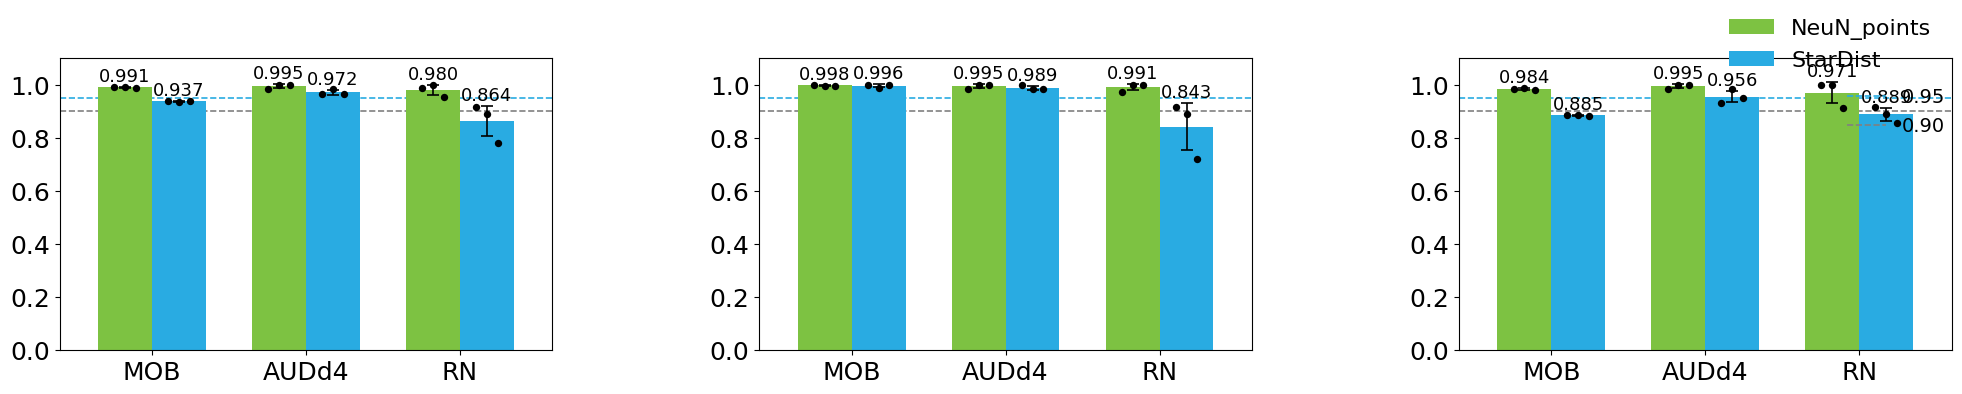

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ==========================================
# font settings
# ==========================================
matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size']   = 18

# ==========================================
# measured counts (n_pred, FP, FN) per ROI
# ==========================================
REGION_DATA = {
    "MOB": {
        "NeuN_points": [(408, 0, 6),  (367, 1, 5),  (315, 1, 6)],
        "StarDist":    [(201, 0, 26), (182, 2, 23), (174, 0, 23)],
    },
    "AUDd4": {
        "NeuN_points": [(69, 1, 1),  (64, 0, 0),  (62, 0, 0)],
        "StarDist":    [(68, 0, 5),  (61, 1, 1),  (60, 1, 3)],
    },
    "RN": {
        "NeuN_points": [(38, 1, 0),  (37, 0, 0),  (21, 0, 2)],
        "StarDist":    [(36, 3, 3),  (37, 4, 4),  (25, 7, 3)],
    },
}

def calc_metrics(n_pred, FP, FN):
    TP = max(n_pred - FP, 0)
    n_gt = TP + FN
    precision = TP / n_pred if n_pred > 0 else 0.0
    recall    = TP / n_gt   if n_gt   > 0 else 0.0
    f1 = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0
    return f1, precision, recall

results = {}
for region, methods in REGION_DATA.items():
    results[region] = {}
    for method, roi_list in methods.items():
        f1s, precs, recs = [], [], []
        for (n_pred, FP, FN) in roi_list:
            f1, prec, rec = calc_metrics(n_pred, FP, FN)
            f1s.append(f1); precs.append(prec); recs.append(rec)
        results[region][method] = {"F1": f1s, "Precision": precs, "Recall": recs}

# ==========================================
# plot settings
# ==========================================
REGIONS  = ["MOB",  "AUDd4", "RN"]
METRICS  = ["F1", "Precision", "Recall"]
METHODS  = ["NeuN_points", "StarDist"]

METHOD_COLORS = {"NeuN_points": "#7DC242", "StarDist": "#29ABE2"}
METRIC_YLABELS = {"F1": "F1 Score", "Precision": "Precision", "Recall": "Recall"}

bar_width  = 0.35
x          = np.arange(len(REGIONS))
dot_jitter = [-0.07, 0.0, 0.07]

# larger figsize
fig, axes = plt.subplots(1, 3, figsize=(22, 4))
fig.subplots_adjust(wspace=0.42, left=0.07, right=0.93, top=0.85, bottom=0.12)

for col_idx, metric in enumerate(METRICS):
    ax = axes[col_idx]

    for m_idx, method in enumerate(METHODS):
        color   = METHOD_COLORS[method]
        offsets = x + (m_idx - 0.5) * bar_width

        means = np.array([np.mean(results[region][method][metric]) for region in REGIONS])
        stds  = np.array([np.std( results[region][method][metric], ddof=0) for region in REGIONS])
        rois  = [results[region][method][metric] for region in REGIONS]

        ax.bar(offsets, means, width=bar_width,
               color=color, edgecolor='none', zorder=2)

        ax.errorbar(offsets, means, yerr=stds,
                    fmt='none', ecolor='black',
                    elinewidth=1.2, capsize=4, capthick=1.2, zorder=3)

        # mean-value label above each bar
        for xi, mean_val, std_val in zip(offsets, means, stds):
            ax.text(xi, mean_val + std_val + 0.006,
                    f"{mean_val:.3f}",
                    ha='center', va='bottom', fontsize=13)

        # per-ROI points
        for xi, roi_vals in zip(offsets, rois):
            for j, val in enumerate(roi_vals):
                ax.scatter(xi + dot_jitter[j], val,
                           color='black', s=28, zorder=4, linewidths=0)

    # reference lines
    ax.axhline(0.95, color='#29ABE2', linestyle='--', linewidth=1.2, zorder=1)
    ax.axhline(0.90, color='gray',    linestyle='--', linewidth=1.2, zorder=1)

    # axis range
    # axis range
    ax.set_xlim(-0.6, len(REGIONS) - 0.4)
    ax.set_ylim(0.0, 1.10)

    ax.set_xticks(x)
    ax.set_xticklabels(REGIONS, fontsize=18)

    yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(yticks)
    ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'], )


# legend (method)
legend_elements = [
    Patch(facecolor=METHOD_COLORS[m], label=m) for m in METHODS
]
fig.legend(handles=legend_elements,
           loc='upper right', bbox_to_anchor=(0.93, 1.00),
           frameon=False, fontsize=16)

# reference-line legend
ref_lines = [
    Line2D([0],[0], color='#29ABE2', linestyle='--', linewidth=1.2, label='0.95'),
    Line2D([0],[0], color='gray',    linestyle='--', linewidth=1.2, label='0.90'),
]
fig.legend(handles=ref_lines,
           loc='upper right', bbox_to_anchor=(0.935, 0.82),
           frameon=False, fontsize=14)

plt.show()

# ==========================================
# save PDF
# ==========================================
out_dir  = ""
pdf_path = out_dir + "ED20_StarDist_accuracy_F1_precision_recall.pdf"

with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')

print(f"Saved: {pdf_path}")
